<a href="https://colab.research.google.com/github/tejinderpa/Machine-Learning/blob/feature%2Fweb-scraping/GradientBoostingFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)


import pandas as pd


df = pd.DataFrame()


df['X'] = X.reshape(100)
df['y'] = y


df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs Y')

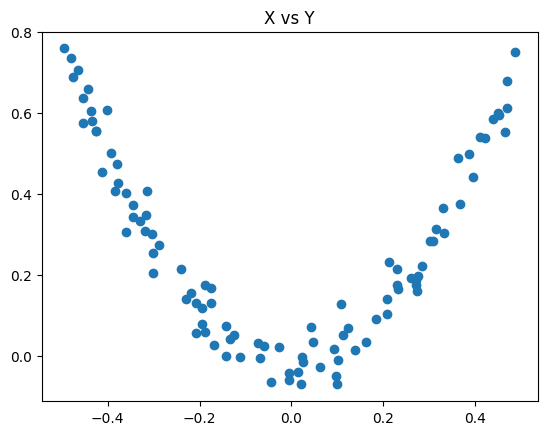

In [2]:

plt.scatter(df['X'],df['y'])
plt.title('X vs Y')

In [3]:
df['pred1'] =df['y'].mean()

In [4]:
df['pred1']

,pred1
0,0.265458
1,0.265458
2,0.265458
3,0.265458
4,0.265458
...,...
95,0.265458
96,0.265458
97,0.265458
98,0.265458


In [5]:
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [6]:
df['rest1'] = df['y'] - df['pred1']

In [7]:
df

,X,y,pred1,rest1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


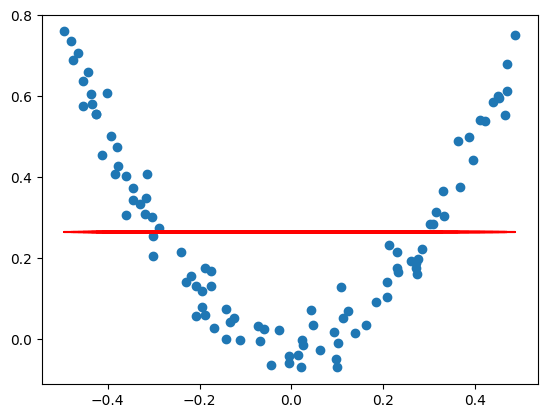

In [10]:
plt.scatter(df['X'], df['y'])
plt.plot(df['X'], df['pred1'], color='red')

In [11]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=10)

In [14]:
tree1.fit(df['X'].values.reshape(100, 1), df['rest1'].values)

DecisionTreeRegressor(max_leaf_nodes=10)

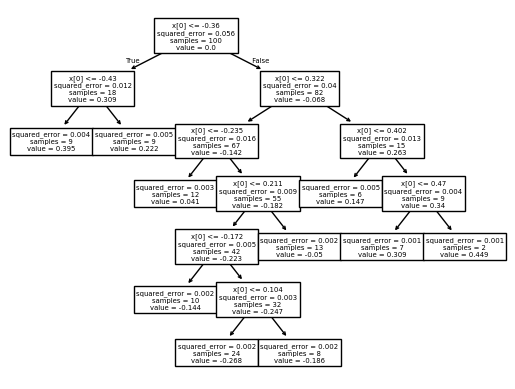

In [15]:


from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [20]:
X_test = np.linspace(-0.5, 0.5, 500)
y_pred1 = 0.265458 + tree1.predict(X_test.reshape(500, 1))

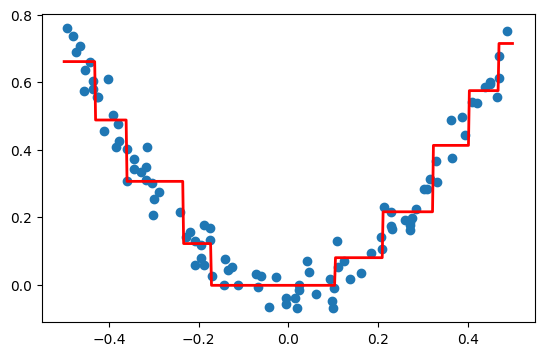

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred1, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [27]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100, 1))

In [28]:
df

,X,y,pred1,rest1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,-0.002160
1,0.450714,0.594480,0.265458,0.329021,0.574829
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,-0.002160
4,-0.343981,0.343986,0.265458,0.078528,0.305964
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.002160
96,0.022733,-0.002305,0.265458,-0.267763,-0.002160
97,-0.072459,0.032809,0.265458,-0.232650,-0.002160
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [29]:
df['res2'] = df['y'] - df['pred2']

In [30]:
df

,X,y,pred1,rest1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,-0.002160,0.053732
1,0.450714,0.594480,0.265458,0.329021,0.574829,0.019651
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,-0.002160,-0.068018
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.002160,-0.038515
96,0.022733,-0.002305,0.265458,-0.267763,-0.002160,-0.000145
97,-0.072459,0.032809,0.265458,-0.232650,-0.002160,0.034968
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [31]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=10)

In [32]:
tree2.fit(df['X'].values.reshape(100, 1), df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=10)

In [33]:
y_pred2 = 0.265458 + tree1.predict(X_test.reshape(-1, 1)) + tree2.predict(X_test.reshape(-1, 1))

In [37]:
y_pred2

array([ 0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.55597108,  0.55597108,  0.55597108,  0.55597108,  0.55597108,
        0.55597108,  0.45490008,  0.45490008,  0.45490008,  0.45490008,
        0.45490008,  0.45490008,  0.60876529,  0.60876529,  0.60876529,
        0.60876529,  0.60876529,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44

In [38]:
y_pred3 = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])


In [39]:
y_pred3

array([ 0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.55597108,  0.55597108,  0.55597108,  0.55597108,  0.55597108,
        0.55597108,  0.45490008,  0.45490008,  0.45490008,  0.45490008,
        0.45490008,  0.45490008,  0.60876529,  0.60876529,  0.60876529,
        0.60876529,  0.60876529,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44291277,
        0.44291277,  0.44291277,  0.44291277,  0.44291277,  0.44

Text(0.5, 1.0, 'X vs y')

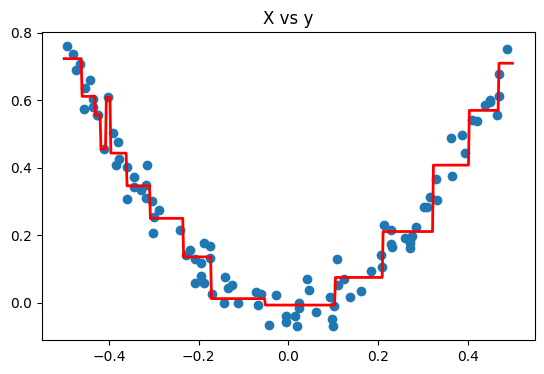

In [35]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred2, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [40]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)




In [ ]:

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)